In [1]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from pathlib import Path
import dill as pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.ndimage import gaussian_filter1d
import tedeous
from tedeous.data import Domain, Conditions, Equation
from tedeous.model import Model
from tedeous.callbacks import early_stopping, plot
from typing import List, Dict, Tuple, Any, Optional
from tedeous.optimizers.optimizer import Optimizer
from tedeous.device import solver_device, check_device
from tedeous.models import mat_model
from scipy import stats
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import pairwise_distances
from tedeous.models import Fourier_embedding, SineLayer, FourierNN, SineCosineLayer, CosineLayer
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import optuna


/opt/anaconda3/envs/Active_Matter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_nearest_robots(coord_data, root_id, n=3):
    root_start = coord_data[root_id][0]  # начальная точка root
    all_starts = np.array([coords[0] for key, coords in coord_data.items()])
    keys = list(coord_data.keys())
    
    distances = pairwise_distances([root_start], all_starts).flatten()
    nearest_idx = np.argsort(distances)[1:n+1]  # исключаем сам root
    nearest_keys = [keys[i] for i in nearest_idx]
    
    return nearest_keys


In [3]:
def split_into_parts(t, num_parts=3):
    total_points = len(t)
    part_size = total_points // num_parts
    boundaries = [i*part_size for i in range(num_parts+1)]
    return boundaries


In [4]:
class DataProcessor:
    """CLASS FOR DATA PREPROCESSING"""

    def __init__(self, data: List):
        self.data = data
        self.coord_data = {}
        self.normalized_coord_data = {}

    def extract_data(self) -> Dict:
        """EXTRACTING RAW DATA"""
        coord_data = {}
        for inner_list in self.data:
            for item in inner_list:
                key = item[0]
                coordinates = item[2]
                if key in coord_data:
                    coord_data[key].append(coordinates)
                else:
                    coord_data[key] = [coordinates]
        self.coord_data = coord_data
        return coord_data

    @staticmethod
    def normalize_to_normal_distribution(data: np.ndarray) -> np.ndarray:
        if np.min(data) <= 0:
            data = data - np.min(data) + 1e-6
        transformed_data, _ = stats.boxcox(data)
        scaler = MinMaxScaler(feature_range=(0, 1))
        normalized_data = scaler.fit_transform(transformed_data.reshape(-1, 1)).flatten()
        return normalized_data

    def normalize_all_coordinates(self) -> Dict:
        """NORMALIZING DATA"""
        all_x, all_y = [], []
        for points in self.coord_data.values():
            points_array = np.array(points)
            all_x.extend(points_array[:, 0])
            all_y.extend(points_array[:, 1])

        x_normalized = self.normalize_to_normal_distribution(np.array(all_x))
        y_normalized = self.normalize_to_normal_distribution(np.array(all_y))

        idx = 0
        for obj_id, points in self.coord_data.items():
            points_array = np.array(points)
            num_points = len(points_array)
            obj_x_norm = x_normalized[idx:idx + num_points]
            obj_y_norm = y_normalized[idx:idx + num_points]
            self.normalized_coord_data[obj_id] = np.column_stack((obj_x_norm, obj_y_norm))
            idx += num_points

        return self.normalized_coord_data

In [ ]:
class RobotSystemBuilder:
    def __init__(self, robot_id: int, num_parts: int = 3, threshold: float = 1.0, mc_samples: int = 10):
        self.robot_id = robot_id
        self.num_parts = num_parts
        self.threshold = threshold
        self.mc_samples = mc_samples
        self.scaler = StandardScaler()

    def normalize_df(self, df: pd.DataFrame) -> pd.DataFrame:
            """Нормализует данные, убирая колонки с нулевой дисперсией."""
            valid_cols = df.columns[df.std() > 1e-12]  # отбрасываем константные столбцы
            if len(valid_cols) == 0:
                return df
            
            df = df[valid_cols].copy()
            scaled = self.scaler.fit_transform(df)
            df_scaled = pd.DataFrame(scaled, columns=valid_cols, index=df.index)
            return df_scaled.fillna(0)


    def generate_monte_carlo(self, df: pd.DataFrame) -> pd.DataFrame:
        """Генерируем шумовые семплы вокруг df"""
        monte_carlo_samples = pd.DataFrame(index=range(self.mc_samples), columns=df.columns)
        for col in df.columns:
            std_dev = df[col].std()
            min_val = df[col].min()
            max_val = df[col].max()
            for i in range(self.mc_samples):
                mean_val = df[col].iloc[i%2]
                sample = mean_val + np.random.normal(scale=std_dev * 0.01)
                monte_carlo_samples.loc[i, col] = np.clip(sample, min_val, max_val)
        return monte_carlo_samples.dropna()

    def filter_by_distance(self, df: pd.DataFrame, samples: pd.DataFrame) -> pd.DataFrame:
        """Выбираем ближайший Monte Carlo сэмпл к строкам 0 и 1 из df"""
        # Считаем расстояния от двух первых строк
        dist_0 = pairwise_distances(df.iloc[[0]], samples)[0]
        dist_1 = pairwise_distances(df.iloc[[1]], samples)[0]
        
        # Индексы минимальных расстояний
        min_idx_0 = dist_0.argmin()
        min_idx_1 = dist_1.argmin()
        
        # Минимальные значения
        min_val_0 = dist_0[min_idx_0]
        min_val_1 = dist_1[min_idx_1]
        
        # Выбираем глобальный минимум
        if min_val_0 <= min_val_1:
            chosen_idx = min_idx_0
        else:
            chosen_idx = min_idx_1
        
        return samples.iloc[[chosen_idx]].reset_index(drop=True)
    
    def construct_equation_dict(self, new_coeff: pd.DataFrame):
        """Используем ваш оригинальный код construct_equation_dict"""
        equations = []
        for index, row in new_coeff.iterrows():
            first_dict ={
            # --- Terms for X equation ---
            'C_x': {'coeff': row.get('C_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'x_x': {'coeff': row.get('x{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'y_x': {'coeff': row.get('y{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
            'dx/dt_x': {'coeff': row.get('dx/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
            'd^2x/dt^2_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
            'dy/dt_x': {'coeff': row.get('dy/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
            'd^2y/dt^2_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
            't_x': {'coeff': row.get('t{power: 1.0, dim: 0.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [0],
                    'grid_term': True},
            't^2_x': {'coeff': row.get('t{power: 2.0, dim: 0.0}_x', 0), 'term': [[None]], 'pow': [2], 'var': [0],
                      'grid_term': True},

            # --- Composite terms for X equation ---
            'x*dx/dt_x': {'coeff': row.get('x{power: 1.0} * dx/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [0, 0]},
            'y*dy/dt_x': {'coeff': row.get('y{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [1, 1]},
            'dx/dt*dy/dt_x': {'coeff': row.get('dx/dx0{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[0], [0]],
                              'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*d^2x/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 0]},
            'dx/dt*d^2y/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*t_x': {'coeff': row.get('dx/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0), 'term': [[0], [None]],
                          'pow': [1, 1], 'var': [0, 0], 'grid_term': [False, True]},
            'd^2y/dt^2*t_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0),
                              'term': [[0, 0], [None]], 'pow': [1, 1], 'var': [1, 0], 'grid_term': [False, True]},
            'd^2y/dt^2*sin_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_x', 0),
                                'term': [[0, 0], [None]], 'pow': [1, 1], 'var': [1, 0], 'like_grad': [False, True]},

           }

            second_dict ={
                # --- Terms for Y equation ---
                'C_y': {'coeff': row.get('C_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
                'x_y': {'coeff': row.get('x{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
                'y_y': {'coeff': row.get('y{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
                'dx/dt_y': {'coeff': row.get('dx/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
                'd^2x/dt^2_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
                'dy/dt_y': {'coeff': row.get('dy/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
                'd^2y/dt^2_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
                't_y': {'coeff': row.get('t{power: 1.0, dim: 0.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [0],
                        'grid_term': True},
                't^2_y': {'coeff': row.get('t{power: 2.0, dim: 0.0}_y', 0), 'term': [[None]], 'pow': [2], 'var': [0],
                        'grid_term': True},


                # --- Composite terms for Y equation ---
                'y*d^2y/dt^2_y': {'coeff': row.get('y{power: 1.0} * d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[None], [0, 0]],
                                'pow': [1, 1], 'var': [1, 1]},
                'dy/dt*x_y': {'coeff': row.get('dy/dx0{power: 1.0} * x{power: 1.0}_y', 0), 'term': [[0], [None]],
                            'pow': [1, 1], 'var': [1, 0]},
                'dy/dt*dx/dt_y': {'coeff': row.get('dy/dx0{power: 1.0} * dx/dx0{power: 1.0}_y', 0), 'term': [[0], [0]],
                                'pow': [1, 1], 'var': [1, 0]},
                'dy/dt*d^2x/dt^2_y': {'coeff': row.get('dy/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_y', 0),
                                    'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [1, 0]},
                'd^2x/dt^2*d^2y/dt^2_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * d^2y/dx0^2{power: 1.0}_y', 0),
                                        'term': [[0, 0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
                't*d^2y/dt^2_y': {'coeff': row.get('t{power: 1.0, dim: 0.0} * d^2y/dx0^2{power: 1.0}_y', 0),
                                'term': [[None], [0, 0]], 'pow': [1, 1], 'var': [0, 1], 'grid_term': [True, False]},
                't^2*y_y': {'coeff': row.get('t{power: 2.0, dim: 0.0} * y{power: 1.0}_y', 0), 'term': [[None], [None]],
                            'pow': [2, 1], 'var': [0, 1], 'grid_term': [True, False]},
                'dx/dt*sin_y': {'coeff': row.get('dx/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_y', 0),
                                'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 0], 'like_grad': [False, True]},
                'dx/dt*cos_y': {'coeff': row.get('dx/dx0{power: 1.0} * cos{power: 1.0, dim: 0.0}_y', 0),
                                'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 0], 'like_grad': [False, True]},
            }
            first_dict = {k: v for k, v in first_dict.items() if v['coeff'] != 0}
            second_dict = {k: v for k, v in second_dict.items() if v['coeff'] != 0}
            equations.append((first_dict, second_dict))
        return equations

    def build_system(self, input_dir='./output', num_mc_samples=10):
        robot_dir = os.path.join(input_dir, f'robot_{str(self.robot_id)}')
        os.makedirs(robot_dir, exist_ok=True)

        # теперь структура по сэмплам
        self.equations_all = [[] for _ in range(num_mc_samples)]

        for part in range(1, self.num_parts + 1):
            csv_path = os.path.join(robot_dir, f'system_force_{self.num_parts}{part}.csv')
            df = pd.read_csv(csv_path, index_col=0)
            df = self.normalize_df(df)

            mc_df_list = []

            for mc_idx in range(num_mc_samples):
                mc_samples = self.generate_monte_carlo(df)
                best_sample = self.filter_by_distance(df, mc_samples)
                mc_df_list.append(best_sample)

                eq = self.construct_equation_dict(best_sample)
                self.equations_all[mc_idx].append(eq)   # <── ключевая строка, mc_idx снаружи!

            mc_df_all = pd.concat(mc_df_list, axis=0).reset_index(drop=True)
            mc_path = os.path.join(robot_dir, f'mc_system_force_{self.num_parts}{part}.csv')
            mc_df_all.to_csv(mc_path, index=False)
            print(f"✅ Сохранено {len(mc_df_all)} строк в {mc_path}")

        return self.equations_all


[I 2025-10-28 12:12:00,719] A new study created in memory with name: no-name-108ad644-5de4-4584-acf2-5dfce53eef45


✅ Сохранено 10 строк в ./output/robot_79/mc_system_41.csv
✅ Сохранено 10 строк в ./output/robot_79/mc_system_42.csv
✅ Сохранено 10 строк в ./output/robot_79/mc_system_43.csv
✅ Сохранено 10 строк в ./output/robot_79/mc_system_44.csv

🌌 Monte Carlo сэмпл 1/10

=== 🔍 Оптимизация параметров для части 1/4 ===
ok
ok
[2025-10-28 12:12:00.731961] initial (min) loss is 6405.0419921875


[I 2025-10-28 12:12:01,509] Trial 0 finished with value: 27.224873539543832 and parameters: {'activation_type': None, 'L': 1.5, 'M': 4, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 27.224873539543832.


(1374,) (1374,)
ok
ok
[2025-10-28 12:12:01.521963] initial (min) loss is 8790.5625


[I 2025-10-28 12:12:01,894] Trial 1 finished with value: 46.87911090921635 and parameters: {'activation_type': None, 'L': 1.75, 'M': 4, 'omega_0': None, 'num_layers': 1}. Best is trial 0 with value: 27.224873539543832.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:12:25.387087] initial (min) loss is 419539584.0


[I 2025-10-28 12:12:26,655] Trial 18 finished with value: 57.957191165704295 and parameters: {'activation_type': None, 'L': 0.05, 'M': 6, 'omega_0': None, 'num_layers': 3}. Best is trial 12 with value: 3.877951612392029.


(1374,) (1374,)
ok
ok
[2025-10-28 12:12:26.676761] initial (min) loss is 7683.97314453125


[I 2025-10-28 12:12:29,184] Trial 19 finished with value: 12.632079014098041 and parameters: {'activation_type': None, 'L': 0.75, 'M': 6, 'omega_0': None, 'num_layers': 5}. Best is trial 12 with value: 3.877951612392029.


(1374,) (1374,)
✅ Лучшая комбинация для части 0: {'activation_type': None, 'L': 2.0, 'M': 7, 'omega_0': None, 'num_layers': 5}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:12:29.203954] initial (min) loss is 0.35839515924453735


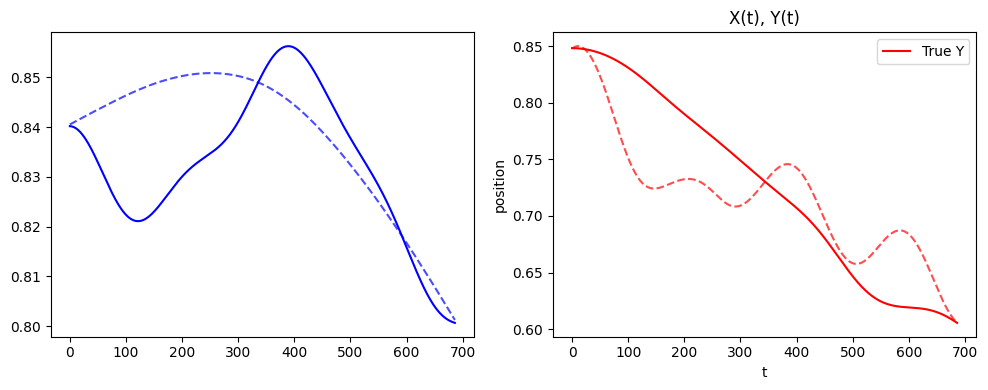

[I 2025-10-28 12:12:40,626] A new study created in memory with name: no-name-3a67a715-d2bc-4117-b457-b8f1424ae37b



=== 🔍 Оптимизация параметров для части 2/4 ===
ok
ok
[2025-10-28 12:12:40.650527] initial (min) loss is 4681.796875


[I 2025-10-28 12:12:42,793] Trial 0 finished with value: 1.9642586380284002 and parameters: {'activation_type': None, 'L': 1.6, 'M': 6, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 1.9642586380284002.


(1374,) (1374,)
ok
ok
[2025-10-28 12:12:42.812627] initial (min) loss is 4648.54736328125


[I 2025-10-28 12:12:45,023] Trial 1 finished with value: 2.120027631522396 and parameters: {'activation_type': None, 'L': 0.5, 'M': 3, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 1.9642586380284002.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:13:15.914549] initial (min) loss is 4003.482666015625


[I 2025-10-28 12:13:18,581] Trial 18 finished with value: 2.5707022702652846 and parameters: {'activation_type': None, 'L': 1.3, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 7 with value: 1.8954590095164574.


(1374,) (1374,)
ok
ok
[2025-10-28 12:13:18.596396] initial (min) loss is 5299.74462890625


[I 2025-10-28 12:13:20,216] Trial 19 finished with value: 2.007580361432274 and parameters: {'activation_type': None, 'L': 1.75, 'M': 8, 'omega_0': None, 'num_layers': 3}. Best is trial 7 with value: 1.8954590095164574.


(1374,) (1374,)
✅ Лучшая комбинация для части 1: {'activation_type': None, 'L': 1.25, 'M': 5, 'omega_0': None, 'num_layers': 4}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:13:20.235389] initial (min) loss is 0.4076094627380371


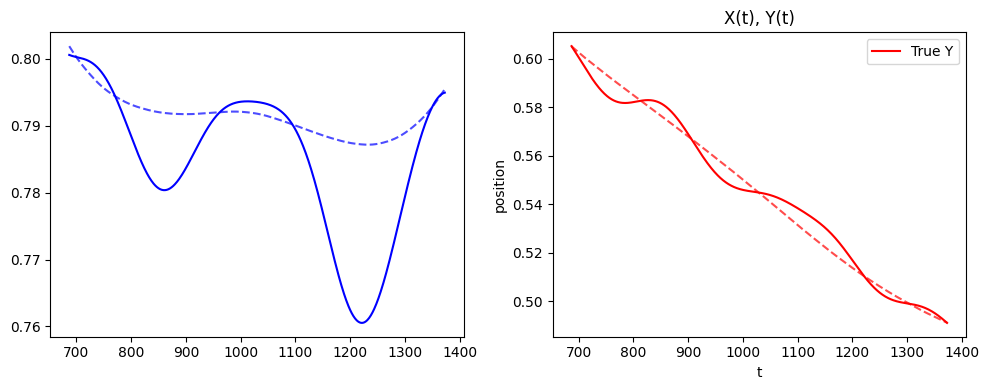

[I 2025-10-28 12:13:31,225] A new study created in memory with name: no-name-325fb9e1-97af-490b-819a-8d5a4e51d250



=== 🔍 Оптимизация параметров для части 3/4 ===
ok
ok
[2025-10-28 12:13:31.247664] initial (min) loss is 3658.98095703125


[I 2025-10-28 12:13:33,107] Trial 0 finished with value: 14.833440899798738 and parameters: {'activation_type': None, 'L': 2.5, 'M': 8, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 14.833440899798738.


(1374,) (1374,)
ok
ok
[2025-10-28 12:13:33.120410] initial (min) loss is 191165.9375


[I 2025-10-28 12:13:34,379] Trial 1 finished with value: 40.04569727983275 and parameters: {'activation_type': None, 'L': 0.25, 'M': 4, 'omega_0': None, 'num_layers': 3}. Best is trial 0 with value: 14.833440899798738.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:14:01.248707] initial (min) loss is 5160.33642578125


[I 2025-10-28 12:14:02,924] Trial 18 finished with value: 2.1487673718154463 and parameters: {'activation_type': None, 'L': 1.75, 'M': 1, 'omega_0': None, 'num_layers': 4}. Best is trial 11 with value: 1.8597685422452899.


(1374,) (1374,)
ok
ok
[2025-10-28 12:14:02.937987] initial (min) loss is 13523.390625


[I 2025-10-28 12:14:04,090] Trial 19 finished with value: 36.29085673395239 and parameters: {'activation_type': None, 'L': 0.5, 'M': 3, 'omega_0': None, 'num_layers': 3}. Best is trial 11 with value: 1.8597685422452899.


(1374,) (1374,)
✅ Лучшая комбинация для части 2: {'activation_type': None, 'L': 1.1, 'M': 1, 'omega_0': None, 'num_layers': 5}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:14:04.108646] initial (min) loss is 0.3904869258403778


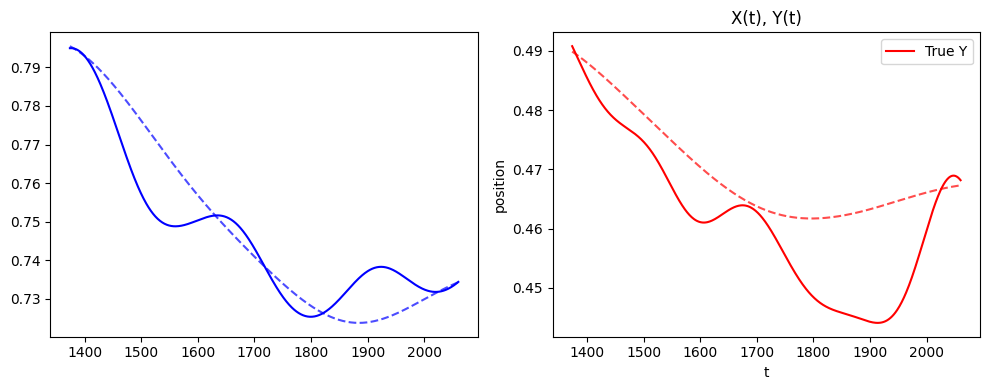

[I 2025-10-28 12:14:15,623] A new study created in memory with name: no-name-6b3c2093-be59-4511-90b9-adf4ff41ae0b



=== 🔍 Оптимизация параметров для части 4/4 ===
ok
ok
[2025-10-28 12:14:15.639801] initial (min) loss is 2716.88818359375


[I 2025-10-28 12:14:16,906] Trial 0 finished with value: 2.7359351999308146 and parameters: {'activation_type': None, 'L': 1.1, 'M': 1, 'omega_0': None, 'num_layers': 3}. Best is trial 0 with value: 2.7359351999308146.


(1374,) (1374,)
ok
ok
[2025-10-28 12:14:16.916794] initial (min) loss is 3213.148681640625


[I 2025-10-28 12:14:17,629] Trial 1 finished with value: 2.1498631443389202 and parameters: {'activation_type': None, 'L': 0.25, 'M': 1, 'omega_0': None, 'num_layers': 2}. Best is trial 1 with value: 2.1498631443389202.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:14:39.980175] initial (min) loss is 43324.12109375


[I 2025-10-28 12:14:40,370] Trial 18 finished with value: 27.98078198151141 and parameters: {'activation_type': None, 'L': 0.5, 'M': 4, 'omega_0': None, 'num_layers': 1}. Best is trial 15 with value: 1.7601181779675223.


(1374,) (1374,)
ok
ok
[2025-10-28 12:14:40.383164] initial (min) loss is 60339332.0


[I 2025-10-28 12:14:41,314] Trial 19 finished with value: 50.75015019674617 and parameters: {'activation_type': None, 'L': 0.1, 'M': 5, 'omega_0': None, 'num_layers': 2}. Best is trial 15 with value: 1.7601181779675223.


(1374,) (1374,)
✅ Лучшая комбинация для части 3: {'activation_type': None, 'L': 2.5, 'M': 2, 'omega_0': None, 'num_layers': 2}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:14:41.325791] initial (min) loss is 1.1454254388809204


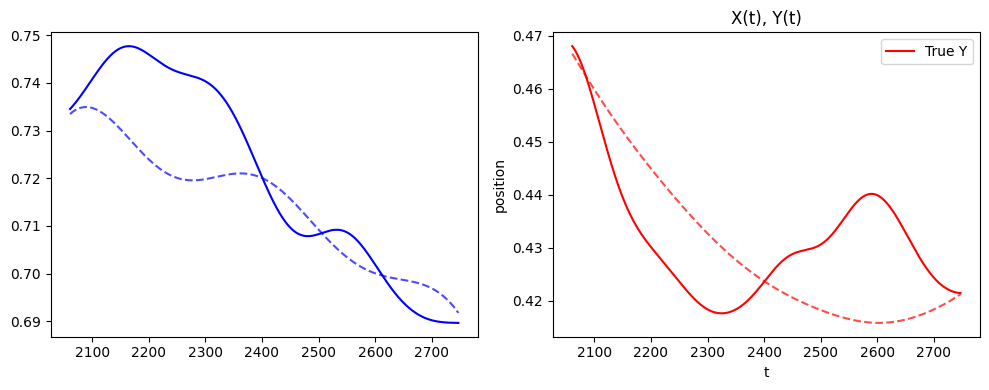

[I 2025-10-28 12:14:45,248] A new study created in memory with name: no-name-e0ab0b36-0fa9-4e48-930f-1d771ab7f651


📈 Metrics for trajectory:
  RMSE_x = 0.01930, RMSE_y = 0.03048
  CRPS_x = 0.01514, CRPS_y = 0.02297

🌌 Monte Carlo сэмпл 2/10

=== 🔍 Оптимизация параметров для части 1/4 ===
yes
ok
ok
[2025-10-28 12:14:45.274942] initial (min) loss is 6008.498046875


[I 2025-10-28 12:14:47,746] Trial 0 finished with value: 9.80353988707925 and parameters: {'activation_type': None, 'L': 2.0, 'M': 7, 'omega_0': None, 'num_layers': 5}. Best is trial 0 with value: 9.80353988707925.


(1374,) (1374,)
ok
ok
[2025-10-28 12:14:47.755169] initial (min) loss is 10116.6787109375


[I 2025-10-28 12:14:48,078] Trial 1 finished with value: 11.951267232747147 and parameters: {'activation_type': None, 'L': 1.0, 'M': 1, 'omega_0': None, 'num_layers': 1}. Best is trial 0 with value: 9.80353988707925.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:15:12.886371] initial (min) loss is 8430.40625


[I 2025-10-28 12:15:14,061] Trial 18 finished with value: 8.244779349691353 and parameters: {'activation_type': None, 'L': 1.5, 'M': 2, 'omega_0': None, 'num_layers': 3}. Best is trial 17 with value: 1.9490713996403275.


(1374,) (1374,)
ok
ok
[2025-10-28 12:15:14.074884] initial (min) loss is 6275.85986328125


[I 2025-10-28 12:15:15,299] Trial 19 finished with value: 2.1315859574542317 and parameters: {'activation_type': None, 'L': 2.5, 'M': 2, 'omega_0': None, 'num_layers': 3}. Best is trial 17 with value: 1.9490713996403275.


(1374,) (1374,)
✅ Лучшая комбинация для части 0: {'activation_type': None, 'L': 1.5, 'M': 2, 'omega_0': None, 'num_layers': 3}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:15:15.312135] initial (min) loss is 0.4554426074028015


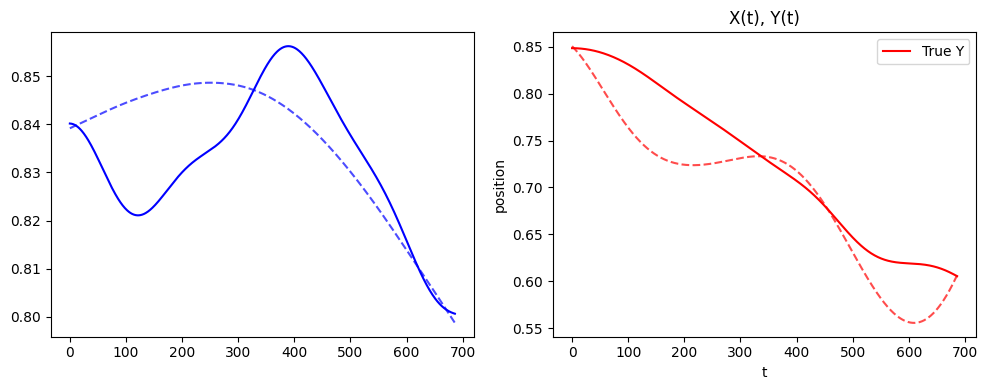

[I 2025-10-28 12:15:21,443] A new study created in memory with name: no-name-607f044e-75d0-40e8-9a1e-264f2a3c5fa6



=== 🔍 Оптимизация параметров для части 2/4 ===
yes
ok
ok
[2025-10-28 12:15:21.465104] initial (min) loss is 5266.7275390625


[I 2025-10-28 12:15:23,751] Trial 0 finished with value: 1.9269229508467058 and parameters: {'activation_type': None, 'L': 1.25, 'M': 5, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 1.9269229508467058.


(1374,) (1374,)
ok
ok
[2025-10-28 12:15:23.769070] initial (min) loss is 3478.790771484375


[I 2025-10-28 12:15:26,116] Trial 1 finished with value: 2.0015524551613493 and parameters: {'activation_type': None, 'L': 1.5, 'M': 5, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 1.9269229508467058.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:15:57.388916] initial (min) loss is 4896.78955078125


[I 2025-10-28 12:15:59,600] Trial 18 finished with value: 1.8885889758295034 and parameters: {'activation_type': None, 'L': 1.6, 'M': 6, 'omega_0': None, 'num_layers': 4}. Best is trial 11 with value: 1.8809146402671906.


(1374,) (1374,)
ok
ok
[2025-10-28 12:15:59.615123] initial (min) loss is 5555.00048828125


[I 2025-10-28 12:16:01,141] Trial 19 finished with value: 1.9232401109198878 and parameters: {'activation_type': None, 'L': 1.6, 'M': 6, 'omega_0': None, 'num_layers': 3}. Best is trial 11 with value: 1.8809146402671906.


(1374,) (1374,)
✅ Лучшая комбинация для части 1: {'activation_type': None, 'L': 2.0, 'M': 5, 'omega_0': None, 'num_layers': 4}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:16:01.157943] initial (min) loss is 0.39771443605422974


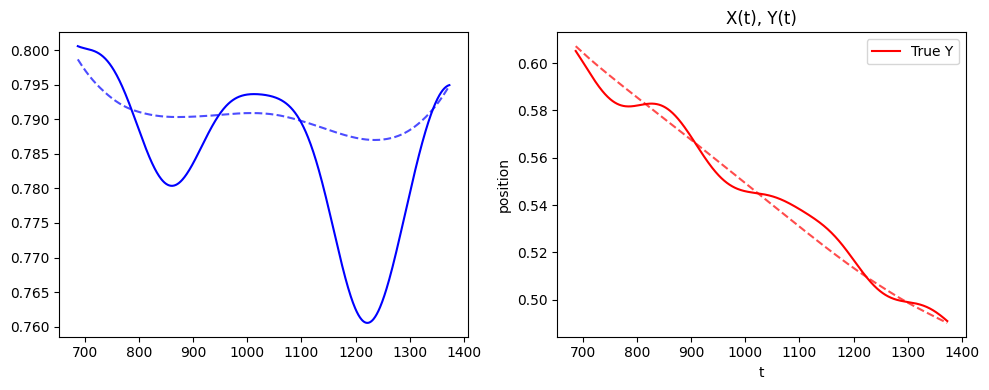

[I 2025-10-28 12:16:13,230] A new study created in memory with name: no-name-4df10616-0b18-442a-818a-69047ad6b203



=== 🔍 Оптимизация параметров для части 3/4 ===
yes
ok
ok
[2025-10-28 12:16:13.250757] initial (min) loss is 4443.5947265625


[I 2025-10-28 12:16:15,414] Trial 0 finished with value: 3.0078949993344035 and parameters: {'activation_type': None, 'L': 1.1, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 0 with value: 3.0078949993344035.


(1374,) (1374,)
ok
ok
[2025-10-28 12:16:15.427385] initial (min) loss is 3561.052001953125


[I 2025-10-28 12:16:16,591] Trial 1 finished with value: 1.9962434109970026 and parameters: {'activation_type': None, 'L': 2.0, 'M': 1, 'omega_0': None, 'num_layers': 3}. Best is trial 1 with value: 1.9962434109970026.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:16:38.994964] initial (min) loss is 3176.184814453125


[I 2025-10-28 12:16:40,793] Trial 18 finished with value: 19.827792742144915 and parameters: {'activation_type': None, 'L': 1.75, 'M': 4, 'omega_0': None, 'num_layers': 4}. Best is trial 1 with value: 1.9962434109970026.


(1374,) (1374,)
ok
ok
[2025-10-28 12:16:40.807513] initial (min) loss is 3861.000244140625


[I 2025-10-28 12:16:42,079] Trial 19 finished with value: 31.659461498868275 and parameters: {'activation_type': None, 'L': 2.5, 'M': 8, 'omega_0': None, 'num_layers': 3}. Best is trial 1 with value: 1.9962434109970026.


(1374,) (1374,)
✅ Лучшая комбинация для части 2: {'activation_type': None, 'L': 2.0, 'M': 1, 'omega_0': None, 'num_layers': 3}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:16:42.092119] initial (min) loss is 0.35334399342536926


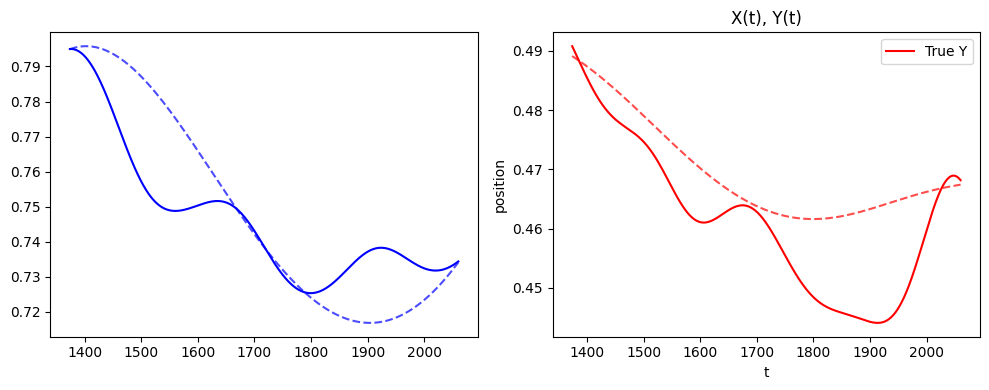

[I 2025-10-28 12:16:48,223] A new study created in memory with name: no-name-18d5bbb8-849f-4ae2-9be4-4e59ba2ae73a



=== 🔍 Оптимизация параметров для части 4/4 ===
yes
ok
ok
[2025-10-28 12:16:48.235357] initial (min) loss is 4179.93115234375


[I 2025-10-28 12:16:49,033] Trial 0 finished with value: 2.34347761170532 and parameters: {'activation_type': None, 'L': 2.5, 'M': 2, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 2.34347761170532.


(1374,) (1374,)
ok
ok
[2025-10-28 12:16:49.044306] initial (min) loss is 4073.076904296875


[I 2025-10-28 12:16:49,844] Trial 1 finished with value: 4.0778348121301535 and parameters: {'activation_type': None, 'L': 1.6, 'M': 2, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 2.34347761170532.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:17:07.599210] initial (min) loss is 32044.814453125


[I 2025-10-28 12:17:09,253] Trial 18 finished with value: 21.147769561131785 and parameters: {'activation_type': None, 'L': 0.5, 'M': 7, 'omega_0': None, 'num_layers': 4}. Best is trial 14 with value: 1.8204371749821238.


(1374,) (1374,)
ok
ok
[2025-10-28 12:17:09.272587] initial (min) loss is 4198.17578125


[I 2025-10-28 12:17:11,403] Trial 19 finished with value: 5.015236130936509 and parameters: {'activation_type': None, 'L': 1.3, 'M': 8, 'omega_0': None, 'num_layers': 5}. Best is trial 14 with value: 1.8204371749821238.


(1374,) (1374,)
✅ Лучшая комбинация для части 3: {'activation_type': None, 'L': 1.1, 'M': 1, 'omega_0': None, 'num_layers': 5}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:17:11.420873] initial (min) loss is 1.131632924079895


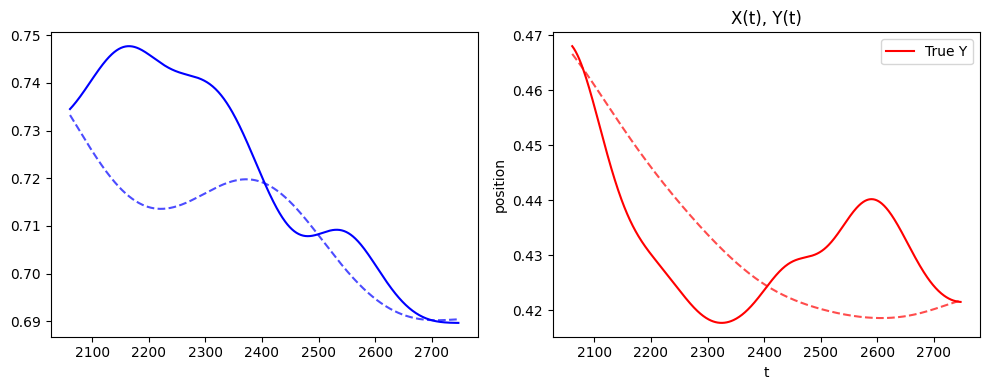

[I 2025-10-28 12:17:21,549] A new study created in memory with name: no-name-ef43ecd4-1e0f-47e7-b6b1-c3b5aa86266d


📈 Metrics for trajectory:
  RMSE_x = 0.02104, RMSE_y = 0.02865
  CRPS_x = 0.01666, CRPS_y = 0.02170

🌌 Monte Carlo сэмпл 3/10

=== 🔍 Оптимизация параметров для части 1/4 ===
yes
ok
ok
[2025-10-28 12:17:21.563667] initial (min) loss is 5971.193359375


[I 2025-10-28 12:17:22,646] Trial 0 finished with value: 10.507901968307808 and parameters: {'activation_type': None, 'L': 1.5, 'M': 2, 'omega_0': None, 'num_layers': 3}. Best is trial 0 with value: 10.507901968307808.


(1374,) (1374,)
ok
ok
[2025-10-28 12:17:22.657979] initial (min) loss is 7431.3603515625


[I 2025-10-28 12:17:23,410] Trial 1 finished with value: 26.56718555919482 and parameters: {'activation_type': None, 'L': 1.3, 'M': 6, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 10.507901968307808.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:17:44.686952] initial (min) loss is 6006.14794921875


[I 2025-10-28 12:17:46,632] Trial 18 finished with value: 2.5095437866722716 and parameters: {'activation_type': None, 'L': 1.8, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 18 with value: 2.5095437866722716.


(1374,) (1374,)
ok
ok
[2025-10-28 12:17:46.650151] initial (min) loss is 6205.65673828125


[I 2025-10-28 12:17:48,601] Trial 19 finished with value: 2.4587826402379775 and parameters: {'activation_type': None, 'L': 1.8, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 19 with value: 2.4587826402379775.


(1374,) (1374,)
✅ Лучшая комбинация для части 0: {'activation_type': None, 'L': 1.8, 'M': 1, 'omega_0': None, 'num_layers': 5}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:17:48.618100] initial (min) loss is 2.7664053440093994


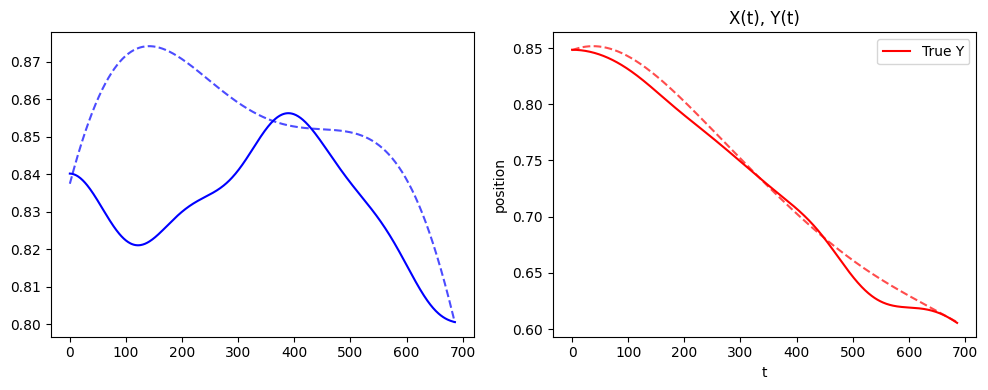

[I 2025-10-28 12:17:58,325] A new study created in memory with name: no-name-7166435d-af85-4057-b6ef-ff9bb0cb4654



=== 🔍 Оптимизация параметров для части 2/4 ===
yes
ok
ok
[2025-10-28 12:17:58.345394] initial (min) loss is 6153.5107421875


[I 2025-10-28 12:18:00,226] Trial 0 finished with value: 1.974532670488942 and parameters: {'activation_type': None, 'L': 2.0, 'M': 5, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 1.974532670488942.


(1374,) (1374,)
ok
ok
[2025-10-28 12:18:00.235214] initial (min) loss is 3559.451171875


[I 2025-10-28 12:18:00,593] Trial 1 finished with value: 3.5183839615570296 and parameters: {'activation_type': None, 'L': 1.0, 'M': 2, 'omega_0': None, 'num_layers': 1}. Best is trial 0 with value: 1.974532670488942.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:18:26.911754] initial (min) loss is 6109.13525390625


[I 2025-10-28 12:18:28,287] Trial 18 finished with value: 1.985943292432506 and parameters: {'activation_type': None, 'L': 2.5, 'M': 4, 'omega_0': None, 'num_layers': 3}. Best is trial 13 with value: 1.9084313239914614.


(1374,) (1374,)
ok
ok
[2025-10-28 12:18:28.307117] initial (min) loss is 4461.69873046875


[I 2025-10-28 12:18:30,527] Trial 19 finished with value: 2.067972166240588 and parameters: {'activation_type': None, 'L': 0.5, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 13 with value: 1.9084313239914614.


(1374,) (1374,)
✅ Лучшая комбинация для части 1: {'activation_type': None, 'L': 1.6, 'M': 5, 'omega_0': None, 'num_layers': 4}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:18:30.544405] initial (min) loss is 0.34427276253700256


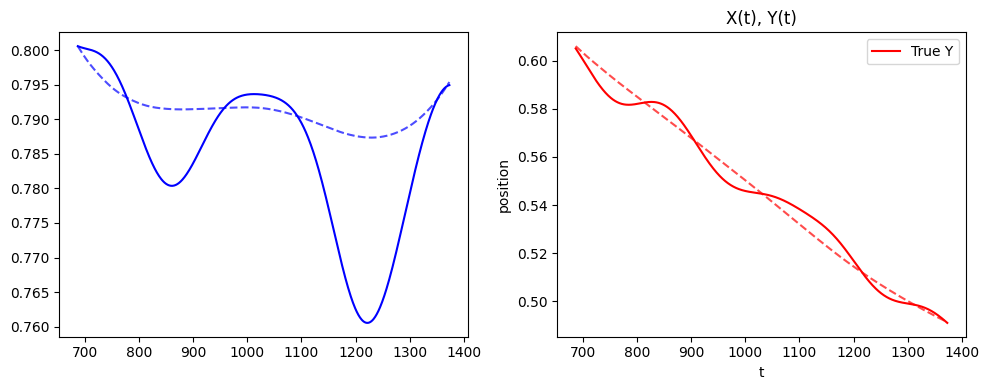

[I 2025-10-28 12:18:39,996] A new study created in memory with name: no-name-7f9fe0e5-3e32-439b-ad61-30f6e5b73563



=== 🔍 Оптимизация параметров для части 3/4 ===
yes
ok
ok
[2025-10-28 12:18:40.011091] initial (min) loss is 4670.4384765625


[I 2025-10-28 12:18:41,095] Trial 0 finished with value: 2.1531022501831267 and parameters: {'activation_type': None, 'L': 2.0, 'M': 1, 'omega_0': None, 'num_layers': 3}. Best is trial 0 with value: 2.1531022501831267.


(1374,) (1374,)
ok
ok
[2025-10-28 12:18:41.105090] initial (min) loss is 22904.220703125


[I 2025-10-28 12:18:41,474] Trial 1 finished with value: 35.49988231739075 and parameters: {'activation_type': None, 'L': 1.5, 'M': 8, 'omega_0': None, 'num_layers': 1}. Best is trial 0 with value: 2.1531022501831267.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:19:00.776515] initial (min) loss is 3299.1142578125


[I 2025-10-28 12:19:01,968] Trial 18 finished with value: 3.0670380352671653 and parameters: {'activation_type': None, 'L': 1.6, 'M': 1, 'omega_0': None, 'num_layers': 3}. Best is trial 14 with value: 2.0741553392010723.


(1374,) (1374,)
ok
ok
[2025-10-28 12:19:01.986479] initial (min) loss is 37650924.0


[I 2025-10-28 12:19:03,629] Trial 19 finished with value: 41.9244845688533 and parameters: {'activation_type': None, 'L': 0.1, 'M': 7, 'omega_0': None, 'num_layers': 4}. Best is trial 14 with value: 2.0741553392010723.


(1374,) (1374,)
✅ Лучшая комбинация для части 2: {'activation_type': None, 'L': 1.0, 'M': 1, 'omega_0': None, 'num_layers': 3}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:19:03.641426] initial (min) loss is 0.4562875032424927


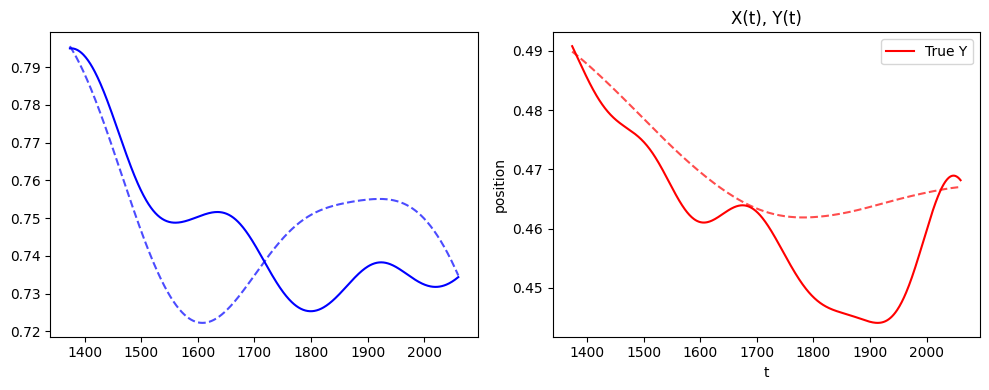

[I 2025-10-28 12:19:09,258] A new study created in memory with name: no-name-2c6ce01f-b35e-4aeb-bda9-d039271390c4



=== 🔍 Оптимизация параметров для части 4/4 ===
yes
ok
ok
[2025-10-28 12:19:09.280167] initial (min) loss is 3536.4833984375


[I 2025-10-28 12:19:11,317] Trial 0 finished with value: 2.5786243593957034 and parameters: {'activation_type': None, 'L': 1.1, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 0 with value: 2.5786243593957034.


(1374,) (1374,)
ok
ok
[2025-10-28 12:19:11.328819] initial (min) loss is 4072.381103515625


[I 2025-10-28 12:19:12,176] Trial 1 finished with value: 14.405331023066639 and parameters: {'activation_type': None, 'L': 1.6, 'M': 7, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 2.5786243593957034.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:19:36.747601] initial (min) loss is 2804.749755859375


[I 2025-10-28 12:19:38,812] Trial 18 finished with value: 2.0280021079596153 and parameters: {'activation_type': None, 'L': 2.0, 'M': 2, 'omega_0': None, 'num_layers': 5}. Best is trial 14 with value: 1.8094928483003314.


(1374,) (1374,)
ok
ok
[2025-10-28 12:19:38.831563] initial (min) loss is 3327.281982421875


[I 2025-10-28 12:19:41,007] Trial 19 finished with value: 3.5623036640428 and parameters: {'activation_type': None, 'L': 2.5, 'M': 7, 'omega_0': None, 'num_layers': 5}. Best is trial 14 with value: 1.8094928483003314.


(1374,) (1374,)
✅ Лучшая комбинация для части 3: {'activation_type': None, 'L': 2.0, 'M': 2, 'omega_0': None, 'num_layers': 5}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:19:41.025194] initial (min) loss is 1.257714867591858


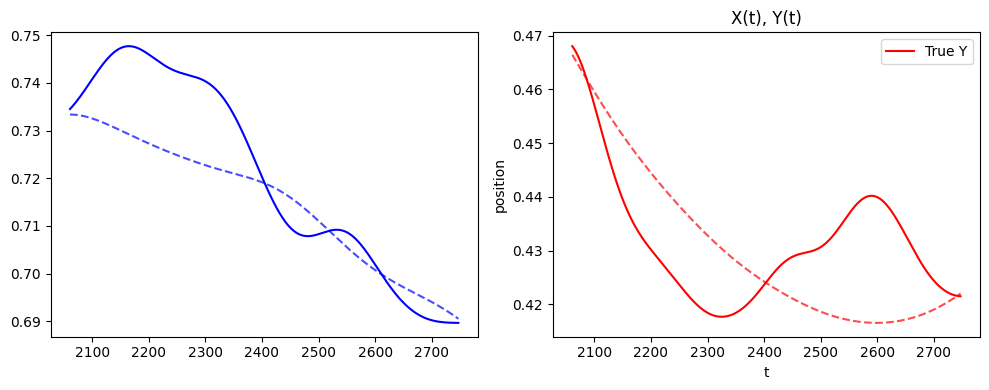

[I 2025-10-28 12:19:51,430] A new study created in memory with name: no-name-feced2bf-8ef0-49b0-800a-1e02c21f3bc1


📈 Metrics for trajectory:
  RMSE_x = 0.02383, RMSE_y = 0.01946
  CRPS_x = 0.01884, CRPS_y = 0.01617

🌌 Monte Carlo сэмпл 4/10

=== 🔍 Оптимизация параметров для части 1/4 ===
yes
ok
ok
[2025-10-28 12:19:51.451675] initial (min) loss is 6509.88671875


[I 2025-10-28 12:19:53,392] Trial 0 finished with value: 2.0947023322141702 and parameters: {'activation_type': None, 'L': 1.8, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 0 with value: 2.0947023322141702.


(1374,) (1374,)
ok
ok
[2025-10-28 12:19:53.407939] initial (min) loss is 19934.01171875


[I 2025-10-28 12:19:55,033] Trial 1 finished with value: 13.043502680758037 and parameters: {'activation_type': None, 'L': 0.75, 'M': 7, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 2.0947023322141702.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:20:14.509779] initial (min) loss is 6253.3671875


[I 2025-10-28 12:20:16,466] Trial 18 finished with value: 2.1543973531019276 and parameters: {'activation_type': None, 'L': 2.5, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 16 with value: 2.015946276354348.


(1374,) (1374,)
ok
ok
[2025-10-28 12:20:16.483389] initial (min) loss is 7309.53173828125


[I 2025-10-28 12:20:18,125] Trial 19 finished with value: 10.00833235841106 and parameters: {'activation_type': None, 'L': 2.5, 'M': 5, 'omega_0': None, 'num_layers': 4}. Best is trial 16 with value: 2.015946276354348.


(1374,) (1374,)
✅ Лучшая комбинация для части 0: {'activation_type': None, 'L': 2.5, 'M': 1, 'omega_0': None, 'num_layers': 5}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:20:18.143008] initial (min) loss is 0.3440397381782532


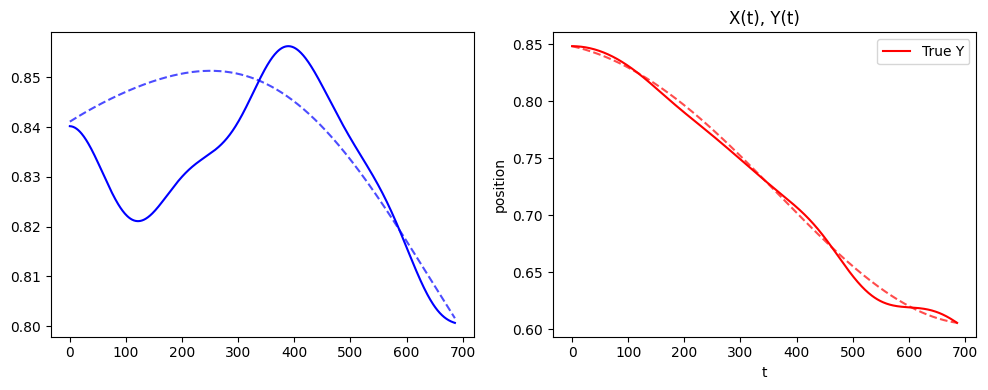

[I 2025-10-28 12:20:28,017] A new study created in memory with name: no-name-d39efbb6-be28-42ba-a984-803627c7b9ab



=== 🔍 Оптимизация параметров для части 2/4 ===
yes
ok
ok
[2025-10-28 12:20:28.037905] initial (min) loss is 6593.4189453125


[I 2025-10-28 12:20:29,870] Trial 0 finished with value: 1.951386045062908 and parameters: {'activation_type': None, 'L': 1.6, 'M': 5, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 1.951386045062908.


(1374,) (1374,)
ok
ok
[2025-10-28 12:20:29.888347] initial (min) loss is 2154476.25


[I 2025-10-28 12:20:31,843] Trial 1 finished with value: 53.36430828051516 and parameters: {'activation_type': None, 'L': 0.125, 'M': 6, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 1.951386045062908.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:20:55.566936] initial (min) loss is 323289600.0


[I 2025-10-28 12:20:56,035] Trial 18 finished with value: 16.352670518256318 and parameters: {'activation_type': None, 'L': 0.1, 'M': 6, 'omega_0': None, 'num_layers': 1}. Best is trial 4 with value: 1.9130607523556147.


(1374,) (1374,)
ok
ok
[2025-10-28 12:20:56.047033] initial (min) loss is 4232.80419921875


[I 2025-10-28 12:20:56,939] Trial 19 finished with value: 2.7247464391218403 and parameters: {'activation_type': None, 'L': 1.8, 'M': 1, 'omega_0': None, 'num_layers': 2}. Best is trial 4 with value: 1.9130607523556147.


(1374,) (1374,)
✅ Лучшая комбинация для части 1: {'activation_type': None, 'L': 1.5, 'M': 4, 'omega_0': None, 'num_layers': 2}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:20:56.950508] initial (min) loss is 1.249962329864502


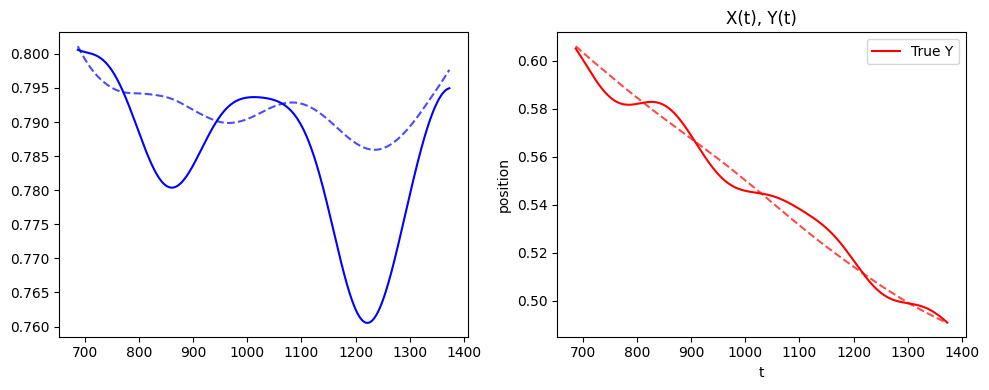

[I 2025-10-28 12:21:01,682] A new study created in memory with name: no-name-5968e618-c201-41fb-bb4d-f1a00bee859c



=== 🔍 Оптимизация параметров для части 3/4 ===
yes
ok
ok
[2025-10-28 12:21:01.696665] initial (min) loss is 5355.43603515625


[I 2025-10-28 12:21:02,828] Trial 0 finished with value: 1.7306926222291192 and parameters: {'activation_type': None, 'L': 1.0, 'M': 1, 'omega_0': None, 'num_layers': 3}. Best is trial 0 with value: 1.7306926222291192.


(1374,) (1374,)
ok
ok
[2025-10-28 12:21:02.841908] initial (min) loss is 803697.1875


[I 2025-10-28 12:21:04,037] Trial 1 finished with value: 26.62263827331221 and parameters: {'activation_type': None, 'L': 0.05, 'M': 2, 'omega_0': None, 'num_layers': 3}. Best is trial 0 with value: 1.7306926222291192.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:21:22.297386] initial (min) loss is 4472.23388671875


[I 2025-10-28 12:21:23,810] Trial 18 finished with value: 3.110277022570688 and parameters: {'activation_type': None, 'L': 1.5, 'M': 1, 'omega_0': None, 'num_layers': 3}. Best is trial 0 with value: 1.7306926222291192.


(1374,) (1374,)
ok
ok
[2025-10-28 12:21:23.826375] initial (min) loss is 3100.3359375


[I 2025-10-28 12:21:24,677] Trial 19 finished with value: 4.683801688273678 and parameters: {'activation_type': None, 'L': 2.5, 'M': 3, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 1.7306926222291192.


(1374,) (1374,)
✅ Лучшая комбинация для части 2: {'activation_type': None, 'L': 1.0, 'M': 1, 'omega_0': None, 'num_layers': 3}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:21:24.690816] initial (min) loss is 0.5018385052680969


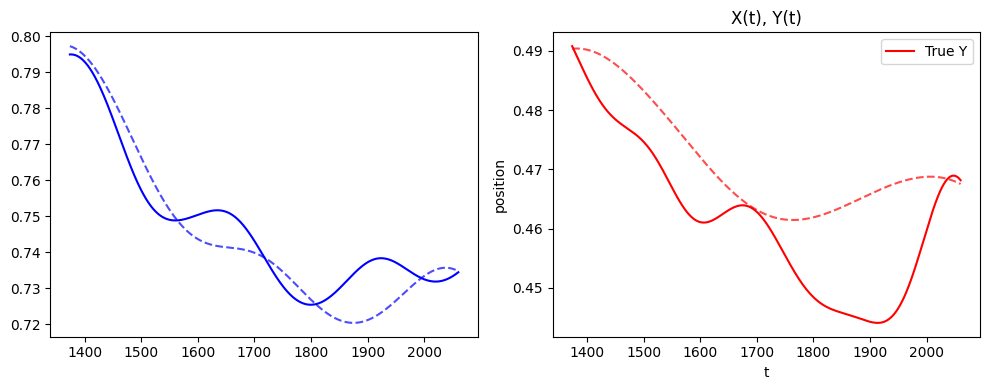

[I 2025-10-28 12:21:31,285] A new study created in memory with name: no-name-228eec43-167e-4ea8-a21d-8569decf2ac4



=== 🔍 Оптимизация параметров для части 4/4 ===
yes
ok
ok
[2025-10-28 12:21:31.308051] initial (min) loss is 2895.896728515625


[I 2025-10-28 12:21:33,715] Trial 0 finished with value: 1.8153444536095675 and parameters: {'activation_type': None, 'L': 2.0, 'M': 2, 'omega_0': None, 'num_layers': 5}. Best is trial 0 with value: 1.8153444536095675.


(1374,) (1374,)
ok
ok
[2025-10-28 12:21:33.725342] initial (min) loss is 7942.12158203125


[I 2025-10-28 12:21:34,138] Trial 1 finished with value: 34.89964532457264 and parameters: {'activation_type': None, 'L': 1.3, 'M': 4, 'omega_0': None, 'num_layers': 1}. Best is trial 0 with value: 1.8153444536095675.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:22:01.128255] initial (min) loss is 519380.4375


[I 2025-10-28 12:22:03,431] Trial 18 finished with value: 21.77741740928529 and parameters: {'activation_type': None, 'L': 0.05, 'M': 2, 'omega_0': None, 'num_layers': 5}. Best is trial 0 with value: 1.8153444536095675.


(1374,) (1374,)
ok
ok
[2025-10-28 12:22:03.442927] initial (min) loss is 2417.6083984375


[I 2025-10-28 12:22:04,284] Trial 19 finished with value: 6.738916767748542 and parameters: {'activation_type': None, 'L': 0.75, 'M': 1, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 1.8153444536095675.


(1374,) (1374,)
✅ Лучшая комбинация для части 3: {'activation_type': None, 'L': 2.0, 'M': 2, 'omega_0': None, 'num_layers': 5}
🔁 Загружены лучшие веса для дообучения этой части
ok
ok
[2025-10-28 12:22:04.302524] initial (min) loss is 2.218672752380371


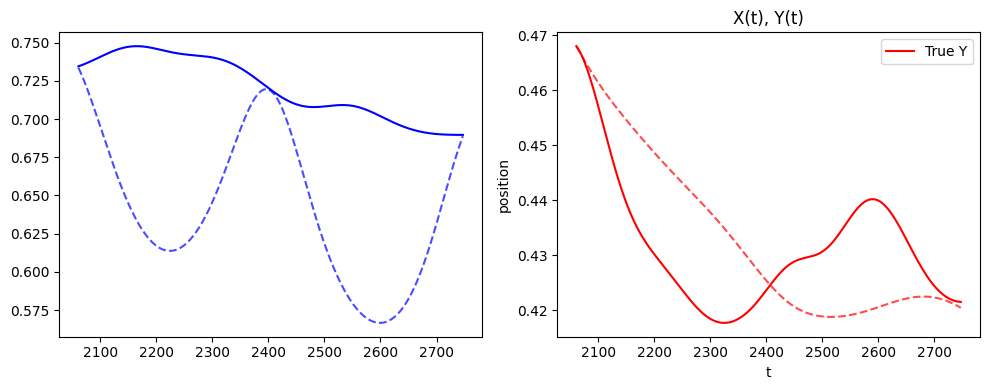

[I 2025-10-28 12:22:15,746] A new study created in memory with name: no-name-4be56038-6f15-431d-8d6f-4e18611f891a


📈 Metrics for trajectory:
  RMSE_x = 0.04948, RMSE_y = 0.01948
  CRPS_x = 0.03119, CRPS_y = 0.01623

🌌 Monte Carlo сэмпл 5/10

=== 🔍 Оптимизация параметров для части 1/4 ===
yes
ok
ok
[2025-10-28 12:22:15.773699] initial (min) loss is 5272.76904296875


[I 2025-10-28 12:22:17,754] Trial 0 finished with value: 2.0728887967843264 and parameters: {'activation_type': None, 'L': 2.5, 'M': 1, 'omega_0': None, 'num_layers': 5}. Best is trial 0 with value: 2.0728887967843264.


(1374,) (1374,)
ok
ok
[2025-10-28 12:22:17.767146] initial (min) loss is 13099.853515625


[I 2025-10-28 12:22:18,714] Trial 1 finished with value: 33.857139087007035 and parameters: {'activation_type': None, 'L': 1.6, 'M': 8, 'omega_0': None, 'num_layers': 2}. Best is trial 0 with value: 2.0728887967843264.


...

(1374,) (1374,)
ok
ok
[2025-10-28 12:22:27.341467] initial (min) loss is 12530.2607421875


[I 2025-10-28 12:22:27,775] Trial 9 finished with value: 35.93679630194117 and parameters: {'activation_type': None, 'L': 2.0, 'M': 8, 'omega_0': None, 'num_layers': 1}. Best is trial 0 with value: 2.0728887967843264.


(1374,) (1374,)
ok
ok
[2025-10-28 12:22:27.792522] initial (min) loss is 5092.2431640625


[I 2025-10-28 12:22:29,536] Trial 10 finished with value: 7.88185071381704 and parameters: {'activation_type': None, 'L': 2.5, 'M': 4, 'omega_0': None, 'num_layers': 4}. Best is trial 0 with value: 2.0728887967843264.


(1374,) (1374,)
ok
ok
[2025-10-28 12:22:29.555004] initial (min) loss is 6980.9384765625


In [ ]:
class RobotTrajectorySolver:
    def __init__(self, x, y, t, equations_list, num_parts=4,
                 sigma=50, epochs=500, lambda_operator=1, lambda_bound=10000,
                 lr=1e-3, device='cpu', mode='NN',
                 L=1/4, M=1, omega_0=1e-3,omega_1=1e-3,
                 num_layers=5, hidden_dim=100, activation_type="sine"): 
        self.activation_type = activation_type
        self.x = x
        self.y = y
        self.t = t
        self.equations_list = equations_list
        self.num_parts = num_parts
        self.sigma = sigma
        self.epochs = epochs
        self.lambda_operator = lambda_operator
        self.lambda_bound = lambda_bound
        self.lr = lr
        self.device = device
        self.mode = mode
        self.L = L
        self.M = M
        self.omega_0 = omega_0
        self.omega_1 = omega_1
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.total_points = len(t)
        self.part_size = self.total_points // num_parts
        self.boundaries_idx = [i * self.part_size for i in range(num_parts + 1)]

        # Сглаженные траектории
        self.smooth_x = gaussian_filter1d(x, sigma=sigma)
        self.smooth_y = gaussian_filter1d(y, sigma=sigma)

        self.all_solutions = []

    # ---------------------------------------------
    def _prepare_boundaries(self, part, t_part,solution):
        """Создание граничных условий для одной части"""
        boundaries = Conditions()
        indices = [0,len(t_part)//2, len(t_part) - 1]
        
        if part == 0:
            for idx in indices:
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx]]),
                    value=torch.tensor([[self.smooth_x[idx]]]).float(),
                    var=0
                )
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx]]),
                    value=torch.tensor([[self.smooth_y[idx]]]).float(),
                    var=1
                )
        else:
            prev_sol = solution[-1]
            # первая точка - связываем с предыдущим решением
            boundaries.dirichlet(
                bnd=torch.Tensor([0.0]),
                value=torch.tensor([[prev_sol[0]]]).float(),
                var=0
            )
            boundaries.dirichlet(
                bnd=torch.Tensor([0.0]),
                value=torch.tensor([[prev_sol[1]]]).float(),
                var=1
            )
            # вторая точка - по данным
            idx = indices[1]
            global_idx = self.boundaries_idx[part] + idx
            boundaries.dirichlet(
                bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                value=torch.tensor([[self.smooth_x[global_idx]]]).float(),
                var=0
            )
            boundaries.dirichlet(
                bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                value=torch.tensor([[self.smooth_y[global_idx]]]).float(),
                var=1
            )
            if len(indices) > 2:
                idx = indices[2]
                global_idx = self.boundaries_idx[part] + idx
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                    value=torch.tensor([[self.smooth_x[global_idx]]]).float(),
                    var=0
                )
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                    value=torch.tensor([[self.smooth_y[global_idx]]]).float(),
                    var=1
                )
        print(boundaries)
        return boundaries

    # ---------------------------------------------
    def _build_network(self):
        """Собираем нейросеть с Fourier + SineCosine"""
        if self.L:
            FFL = Fourier_embedding(L=[self.L], M=[self.M])
            layers = [FFL]
            out_features = FFL.out_features
        else:
            layers = []
            out_features = 0
        if self.activation_type == "sine":
            layers.append(SineLayer(max(1,out_features), self.hidden_dim, is_first=True, omega_0=self.omega_0))
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        elif self.activation_type == "cosine":
            layers.append(CosineLayer(max(1,out_features), self.hidden_dim, is_first=True, omega_0=self.omega_0))
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        else:
            layers.append(nn.Linear(out_features, self.hidden_dim))
        #layers.append(CosineLayer(FFL.out_features, self.hidden_dim, is_first=True, omega_0=self.omega_0))#,omega_1=self.omega_1 ))
        

        for _ in range(self.num_layers - 1):
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(self.hidden_dim, 2))
        net = nn.Sequential(*layers).to(self.device)
        return net

    # ---------------------------------------------
    def _train_part(self, part, solution, prev_state_dict=None):
        t_part = self.t[self.boundaries_idx[part]:self.boundaries_idx[part + 1]]
        eqs_part = self.equations_list[part]

        # ✅ Нормализация времени
        t_part_norm = (t_part - t_part.min()) / (t_part.max() - t_part.min())

        domain = Domain()
        domain.variable('t', [0.0, 1.0], len(t_part_norm))  # теперь t всегда в [0,1]

        eq = Equation()
        for first_dict, second_dict in eqs_part:
            eq.add(first_dict)
            eq.add(second_dict)

        # Передаём нормализованное время для границ
        boundaries = self._prepare_boundaries(part, t_part_norm, solution)

        net = self._build_network()
        if prev_state_dict is not None:
            net.load_state_dict(prev_state_dict)
            print("🔁 Загружены лучшие веса для дообучения этой части")

        model = Model(net, domain, eq, boundaries)
        model.compile(self.mode,
                    lambda_operator=self.lambda_operator,
                    lambda_bound=self.lambda_bound)
        optimizer = Optimizer('Adam', {'lr': self.lr})
        model.train(optimizer, epochs=self.epochs)

        grid = domain.build(self.mode)
        sol = net(grid).detach().cpu().numpy()
        best_state_dict = net.state_dict()
        return sol, best_state_dict

    
    def visualize_part(self, part_idx, pred):
        """Визуализация предсказания и истинных данных для одной части"""
        start = self.boundaries_idx[part_idx]
        end = self.boundaries_idx[part_idx + 1]

        true_x = self.smooth_x[start:end]
        true_y = self.smooth_y[start:end]
        t_part = self.t[start:end]

        pred_x = pred[:, 0]
        pred_y = pred[:, 1]

        plt.figure(figsize=(10, 4))

        # --- 2. Координаты от времени ---
        plt.subplot(1, 2, 1)
        plt.plot(t_part[:len(pred_x)], true_x[:len(pred_x)], 'b-', label='True X')
        plt.plot(t_part[:len(pred_x)], pred_x, 'b--', alpha=0.7)
        plt.subplot(1, 2, 2)
        plt.plot(t_part[:len(pred_y)], true_y[:len(pred_y)], 'r-', label='True Y')
        plt.plot(t_part[:len(pred_y)], pred_y, 'r--', alpha=0.7)
        plt.xlabel("t")
        plt.ylabel("position")
        plt.title("X(t), Y(t)")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # ---------------

def tune_part(part_idx, solver,solution_prev, n_trials=10, prev_best_params=None):
    """
    Подбирает гиперпараметры Optuna для одной части траектории.
    """
    best_state_dict = None
    def objective(trial):
        nonlocal best_state_dict
        # 1️⃣ Предлагаем гиперпараметры
        activation_type = trial.suggest_categorical("activation_type", [None])#"sine", "cosine"])
        L = trial.suggest_categorical("L", [0.01, 0.05, 0.1, 0.125,0.25, 0.5, 0.75, 1.0, 1.1,1.25,1.3,1.5,1.6,1.75, 1.8,2.0, 2.5])
        M = trial.suggest_categorical("M", [1,2,3,4,5,6,7,8])
        omega_0 = trial.suggest_categorical("omega_0", [None])#1e-3, 3e-3, 5e-3, 8e-3, 1e-2, 3e-3, 5e-2, 8e-2, 1e-1])
        #omega_1 = trial.suggest_categorical("omega_1", [1e-3, 3e-3, 5e-3, 8e-3, 1e-2, 3e-3, 5e-2, 8e-2, 1e-1])
        num_layers = trial.suggest_int("num_layers", 1, 5)
        #hidden_dim = trial.suggest_int("hidden_dim", 64, 256, log=True)
        hidden_dim=100
        # 2️⃣ Устанавливаем временно параметры в solver
        solver.activation_type = activation_type
        solver.L = L
        solver.M = M
        solver.omega_0 = omega_0
        #solver.omega_1 = omega_1
        solver.num_layers = num_layers
        solver.hidden_dim = hidden_dim

        try:
            # 3️⃣ Обучаем только одну часть
            pred, state_dict = solver._train_part(part_idx,solution_prev)
            pred=pred[:-1]
            true_x = solver.x[
                solver.boundaries_idx[part_idx]:solver.boundaries_idx[part_idx + 1]
            ]
            true_y = solver.y[
                solver.boundaries_idx[part_idx]:solver.boundaries_idx[part_idx + 1]
            ]
            true = np.hstack([true_x[:len(pred)], true_y[:len(pred)]]).T
            pred_vec = np.hstack([pred[:, 0], pred[:, 1]])
            print(true.shape, pred_vec.shape)
            # Единый RMSE
            rmse_total = np.sqrt(mean_squared_error(true, pred_vec))

            if not hasattr(objective, "best_rmse") or rmse_total < objective.best_rmse:
                objective.best_rmse = rmse_total
                best_state_dict = state_dict

            return rmse_total*100

        except Exception as e:
            print(f"⚠️ Ошибка в части {part_idx}: {e}")
            return float("inf")

    study = optuna.create_study(direction="minimize")
     # если есть прошлое лучшее — запускаем его первым
    if prev_best_params:
        print('yes')
        study.enqueue_trial(prev_best_params)
    study.optimize(objective, n_trials=n_trials)
    print(f"✅ Лучшая комбинация для части {part_idx}: {study.best_params}")
    return study.best_params, best_state_dict

#robot_id = 78
num_parts = 4
num_mc_samples = 10
n_trials=20
sigma=50
best_params_per_part = [{} for _ in range(num_parts)]
all_mc_solutions = []   # сюда будем собирать решения всех MC-сэмплов
all_mc_metrics = [] 
CUT_NUMBER = 2750  # можно сократить для скорости
with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
    raw_data = pickle.load(file)
processor = DataProcessor(raw_data)
processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()
for _, robot_id in enumerate([79,  83, 31, 32 , 34]):
    x = np.array([coord[0] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
    y = np.array([coord[1] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
    t = np.arange(len(x))
    builder = RobotSystemBuilder(robot_id, num_parts=num_parts)

    equations_list = builder.build_system(input_dir='./output',num_mc_samples=num_mc_samples)
    solver = RobotTrajectorySolver(
        x, y, t, equations_list,
        num_parts=num_parts,
        sigma=sigma,
        epochs=100,
        hidden_dim=100,
        omega_0=1e-3,
        omega_1=1e-3
    )
    for mc_idx in range(num_mc_samples):
        print(f"\n==============================")
        print(f"🌌 Monte Carlo сэмпл {mc_idx + 1}/{num_mc_samples}")
        print(f"==============================")
        solver.equations_list = equations_list[mc_idx]
        solution_prev = None
        solver.all_solutions = []
        for part_idx in range(solver.num_parts):
            print(f"\n=== 🔍 Оптимизация параметров для части {part_idx + 1}/{solver.num_parts} ===")
            prev_best_params = best_params_per_part[part_idx] if mc_idx > 0 else None
        
            solver.epochs=100
            best_params, best_state_dict = tune_part(part_idx, solver, solution_prev=solution_prev, 
                                                    n_trials=n_trials, prev_best_params=prev_best_params)
            best_params_per_part[part_idx] = best_params


            # Устанавливаем лучшие найденные параметры
            solver.activation_type = best_params["activation_type"]
            solver.L = best_params["L"]
            solver.M = best_params["M"]
            solver.omega_0 = best_params["omega_0"]
            solver.num_layers = best_params["num_layers"]

            # Обучаем финально с найденными параметрами
            solver.epochs=500
            sol, _  = solver._train_part(part_idx, solution_prev, prev_state_dict=best_state_dict)
            solver.all_solutions.append(sol[:-1])
            solution_prev = sol
            solver.visualize_part(part_idx, sol[:-1])

        # Итоговое решение
        mc_solution = np.vstack(solver.all_solutions)
        all_mc_solutions.append(mc_solution)

        # Метрики для этого сэмпла
        true_x = solver.x[:len(mc_solution)]
        true_y = solver.y[:len(mc_solution)]
        rmse_x = np.sqrt(mean_squared_error(true_x, mc_solution[:, 0]))
        rmse_y = np.sqrt(mean_squared_error(true_y, mc_solution[:, 1]))
        crps_x = np.mean(np.abs(true_x - mc_solution[:, 0]))
        crps_y = np.mean(np.abs(true_y - mc_solution[:, 1]))
        print(f"📈 Metrics for trajectory:")
        print(f"  RMSE_x = {rmse_x:.5f}, RMSE_y = {rmse_y:.5f}")
        print(f"  CRPS_x = {crps_x:.5f}, CRPS_y = {crps_y:.5f}")
        all_mc_metrics.append({'RMSE_x': rmse_x, 'RMSE_y': rmse_y, 'CRPS_x': crps_x, 'CRPS_y': crps_y})

    # --- Конвертируем решения и метрики в numpy / pandas ---
    all_mc_solutions = np.array(all_mc_solutions)  # shape (num_mc_samples, N, 2)
    metrics_df = pd.DataFrame(all_mc_metrics)

    # --- Сохраняем ---
    save_dir = f'./output/robot_{robot_id}'
    os.makedirs(save_dir, exist_ok=True)
    np.save(os.path.join(save_dir, f'solution_force_{num_parts}.npy'), all_mc_solutions)
    metrics_df.to_csv(os.path.join(save_dir, f'metrics_force_{num_parts}.csv'), index=False)

    print(f"✅ Все решения MC-сэмплов и метрики сохранены в {save_dir}")

In [ ]:

# === параметры ===
CUT_NUMBER = 2750
sigma = 50
robot_id = 78
num_parts = num_parts  # как раньше

# === загрузка решений ===
solution_path = Path(f"output/robot_{robot_id}/solution_force_{num_parts}.npy")
all_mc_solutions = np.load(solution_path)  # (num_mc_samples, N, 2)

# === создаём фигуру ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05)

coords = np.array(normalized_coord_data[robot_id][:CUT_NUMBER])
x, y = coords[:, 0], coords[:, 1]
t = np.arange(len(x))

# --- исходные координаты ---
fig.add_trace(go.Scatter(
    x=t, y=x, mode='lines',
    line=dict(color='rgba(100,100,100,0.6)', width=1),
    name=f'Coords., object {robot_id}'
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=t, y=y, mode='lines',
    line=dict(color='rgba(100,100,100,0.6)', width=1),
    name=f'Coords., object {robot_id}', showlegend=False
), row=2, col=1)

# --- сглаженные координаты ---
fig.add_trace(go.Scatter(
    x=t, y=gaussian_filter1d(x, sigma=sigma), mode='lines',
    line=dict(color='green', width=2, dash='dot'),
    name=f'Smooth coords., object {robot_id}'
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=t, y=gaussian_filter1d(y, sigma=sigma), mode='lines',
    line=dict(color='firebrick', width=2, dash='dot'),
    name=f'Smooth coords., object {robot_id}', showlegend=False
), row=2, col=1)

# --- MC-сэмплы ---
mc_solutions = all_mc_solutions[:, :CUT_NUMBER, :]
mean_x = mc_solutions[:, :, 0].mean(axis=0)
mean_y = mc_solutions[:, :, 1].mean(axis=0)
std_x = mc_solutions[:, :, 0].std(axis=0)
std_y = mc_solutions[:, :, 1].std(axis=0)

# доверительный интервал 95%
ci_x_upper = mean_x + 1.96 * std_x
ci_x_lower = mean_x - 1.96 * std_x
ci_y_upper = mean_y + 1.96 * std_y
ci_y_lower = mean_y - 1.96 * std_y

# --- CI X ---
fig.add_trace(go.Scatter(
    x=np.concatenate([t, t[::-1]]),
    y=np.concatenate([ci_x_upper, ci_x_lower[::-1]]),
    fill='toself',
    fillcolor='rgba(50, 168, 82, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    name='95% CI'
), row=1, col=1)

# --- средняя X ---
fig.add_trace(go.Scatter(
    x=t, y=mean_x, mode='lines',
    line=dict(color='darkblue', width=3),
    name=f'Solutions SDE coords., object {robot_id}'
), row=1, col=1)

# --- CI Y ---
fig.add_trace(go.Scatter(
    x=np.concatenate([t, t[::-1]]),
    y=np.concatenate([ci_y_upper, ci_y_lower[::-1]]),
    fill='toself',
    fillcolor='rgba(220, 20, 60, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    name='95% CI'
), row=2, col=1)

# --- средняя Y ---
fig.add_trace(go.Scatter(
    x=t, y=mean_y, mode='lines',
    line=dict(color='darkred', width=3),
    name=f'Solutions SDE coords., object {robot_id}'
), row=2, col=1)

# === оформление ===
fig.update_layout(
    plot_bgcolor='white',
    font=dict(family="Inter", size=14),
    legend=dict(
        x=0.5, y=-0.15, orientation='h',
        xanchor='center', yanchor='top',
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='rgba(0,0,0,0.1)', borderwidth=0.5
    ),
    height=700,
    width=1000,
    margin=dict(l=70, r=30, t=30, b=80)
)

fig.update_xaxes(
    title_text="Time steps",
    showline=True, linewidth=1, linecolor='black',
    mirror=True, gridcolor='lightgrey'
)
fig.update_yaxes(
    title_text="X Coordinate",
    row=1, col=1,
    showline=True, linewidth=1, linecolor='black',
    mirror=True, gridcolor='lightgrey'
)
fig.update_yaxes(
    title_text="Y Coordinate",
    row=2, col=1,
    showline=True, linewidth=1, linecolor='black',
    mirror=True, gridcolor='lightgrey'
)

fig.write_html("XY_with_MC_solutions.html")
fig.show()


In [ ]:
CUT_NUMBER = 2750
num_parts = num_parts  # как раньше
colors_coords = ['DarkOrange']
selected_ids = [robot_id]

# === Загружаем решения MC-сэмплов для роботов ===
solution_path = Path(f"output/robot_{robot_id}/solution_force_{num_parts}.npy")
all_mc_solutions = np.load(solution_path)  # shape (num_mc_samples, N, 2)

# === Создаём фигуру X(t) и Y(t) ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)
for i, rid in enumerate(selected_ids):
    coords = np.array(normalized_coord_data[rid][:CUT_NUMBER])
    x, y = coords[:, 0], coords[:, 1]
    t = np.arange(len(x))
    color_coord = colors_coords[i % len(colors_coords)]
    
    # --- исходные координаты ---
    fig.add_trace(go.Scatter(x=t, y=x, mode='lines', line=dict(color=color_coord, width=1),
                             name=f'X coords., robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=sigma), mode='lines',
                             line=dict(color=color_coord, width=3),
                             name=f'X smooth, robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=y, mode='lines', line=dict(color=color_coord, width=1),
                             name=f'Y coords., robot {rid}'), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=sigma), mode='lines',
                             line=dict(color=color_coord, width=3),
                             name=f'Y smooth, robot {rid}'), row=2, col=1)

    # --- MC-сэмплы: строим среднюю и CI ---
    mc_solutions = np.array(all_mc_solutions)  # shape (num_mc_samples, N, 2)
    mc_solutions = mc_solutions[:, :CUT_NUMBER, :]

    # Средние и стандартные отклонения
    mean_x = mc_solutions[:, :, 0].mean(axis=0)
    mean_y = mc_solutions[:, :, 1].mean(axis=0)
    std_x = mc_solutions[:, :, 0].std(axis=0)
    std_y = mc_solutions[:, :, 1].std(axis=0)

    # 95% доверительный интервал (можно заменить на 1σ при желании)
    ci_x_upper = mean_x + 1.96 * std_x
    ci_x_lower = mean_x - 1.96 * std_x
    ci_y_upper = mean_y + 1.96 * std_y
    ci_y_lower = mean_y - 1.96 * std_y

    # --- CI X ---
fig.add_trace(
    go.Scatter(
        x=np.concatenate([t, t[::-1]]),
        y=np.concatenate([ci_x_upper, ci_x_lower[::-1]]),
        fill='toself',
        fillcolor='rgba(220, 20, 60, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        showlegend=False
    ),
    row=1, col=1
)

# --- средняя X ---
fig.add_trace(
    go.Scatter(
        x=t, y=mean_x,
        mode='lines',
        line=dict(color='Crimson', width=3),
        name=f'Mean X, robot {rid}'
    ),
    row=1, col=1
)

# --- CI Y ---
fig.add_trace(
    go.Scatter(
        x=np.concatenate([t, t[::-1]]),
        y=np.concatenate([ci_y_upper, ci_y_lower[::-1]]),
        fill='toself',
        fillcolor='rgba(220, 20, 60, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        showlegend=False
    ),
    row=2, col=1
)

# --- средняя Y ---
fig.add_trace(
    go.Scatter(
        x=t, y=mean_y,
        mode='lines',
        line=dict(color='Crimson', width=3),
        name=f'Mean Y, robot {rid}'
    ),
    row=2, col=1
)
fig.write_html("XY_with_MC_solutions.html")



In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.ndimage import gaussian_filter1d

CUT_NUMBER = 2750
SIGMA = 50
TARGET_ID = 78
NUM_CLOSEST = 0
num_parts = num_parts  # как раньше
colors_coords = ['DarkOrange', 'DarkBlue', 'DarkRed']
colors_solution = ['Gold', 'CornflowerBlue', 'Crimson']

# === Определяем ближайших роботов ===
target_start = normalized_coord_data[TARGET_ID][0]
selected_ids = [TARGET_ID]
if NUM_CLOSEST > 0:
    distances = {rid: np.linalg.norm(np.array(coords[0]) - target_start)
                 for rid, coords in normalized_coord_data.items() if rid != TARGET_ID}
    closest_ids = sorted(distances, key=distances.get)[:NUM_CLOSEST]
    selected_ids += closest_ids
    print(f"Ближайшие к роботу {TARGET_ID}: {closest_ids}")

# === Загружаем решения MC-сэмплов для роботов ===
solutions_dict = {TARGET_ID: all_mc_solutions}  # shape (num_mc_samples, N, 2)

# === Создаём фигуру X(t) и Y(t) ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)

for i, rid in enumerate(selected_ids):
    coords = np.array(normalized_coord_data[rid][:CUT_NUMBER])
    x, y = coords[:, 0], coords[:, 1]
    t = np.arange(len(x))
    color_coord = colors_coords[i % len(colors_coords)]
    
    # Рисуем исходные координаты
    fig.add_trace(go.Scatter(x=t, y=x, mode='lines', line=dict(color=color_coord, width=1),
                             name=f'X coords., robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=SIGMA), mode='lines',
                             line=dict(color=color_coord, width=3),
                             name=f'X smooth, robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=y, mode='lines', line=dict(color=color_coord, width=1),
                             name=f'Y coords., robot {rid}'), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=SIGMA), mode='lines',
                             line=dict(color=color_coord, width=3),
                             name=f'Y smooth, robot {rid}'), row=2, col=1)

    # Рисуем все MC-сэмплы решений
    mc_solutions = solutions_dict[rid]  # (num_mc_samples, N, 2)
    for j in range(mc_solutions.shape[0]):
        mc_sol = mc_solutions[j][:CUT_NUMBER]
        color_sol = colors_solution[j % len(colors_solution)]
        fig.add_trace(go.Scatter(x=t, y=mc_sol[:, 0], mode='lines',
                                 line=dict(color=color_sol, width=2, dash='dot'),
                                 name=f'MC X sol {j}', showlegend=(i==0)), row=1, col=1)
        fig.add_trace(go.Scatter(x=t, y=mc_sol[:, 1], mode='lines',
                                 line=dict(color=color_sol, width=2, dash='dot'),
                                 name=f'MC Y sol {j}', showlegend=False), row=2, col=1)

# === Настройки графика ===
fig.update_layout(
    legend=dict(x=1.3, y=0.7, xanchor='right', yanchor='middle',
                bgcolor='rgba(255,255,255,0.5)', bordercolor='Black', borderwidth=0.5),
    font_family="Inter Medium",
    plot_bgcolor='white',
    height=600,
    width=900
)
fig.update_xaxes(title_text="Time", row=2, col=1, showgrid=False, mirror=True, ticks='outside',
                 showline=True, linecolor='black', gridcolor='lightgrey', dtick=250)
fig.update_yaxes(title_text="X Coordinate", row=1, col=1, showgrid=False, mirror=True, ticks='outside',
                 showline=True, linecolor='black', gridcolor='lightgrey')
fig.update_yaxes(title_text="Y Coordinate", row=2, col=1, showgrid=False, mirror=True, ticks='outside',
                 showline=True, linecolor='black', gridcolor='lightgrey')

fig.show()
fig.write_html("XY_with_MC_solutions.html")


In [ ]:
'''
def main(target_robot=78, num_parts=2, n_closest=2, CUT_NUMBER = 2750):
    with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
        raw_data = pickle.load(file)

    processor = DataProcessor(raw_data)
    processor.extract_data()
    normalized_coord_data = processor.normalize_all_coordinates()
    all_ids = [target_robot]
    if n_closest>0:
        nearest_ids = get_nearest_robots(normalized_coord_data, target_robot, n=n_closest)
        all_ids += nearest_ids

    solutions_dict = {}
    for robot_id in all_ids:
        x = np.array([coord[0] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
        y = np.array([coord[1] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
        t = np.arange(len(x))
        builder = RobotSystemBuilder(robot_id, num_parts=num_parts)
        equations_list = builder.build_system(input_dir='./output')
        solutions_dict[robot_id] = solve_robot_trajectory(x, y, t,  equations_list, epochs = 500,
                                                          num_parts=num_parts, L=study.best_params['L'],
            M=study.best_params['M'],
            #omega_0=study.best_params['omega_0'],
            num_layers=study.best_params['num_layers'],
            hidden_dim=100)
        pred = solutions_dict[robot_id][:CUT_NUMBER]
        true = np.vstack([x[:len(pred)], y[:len(pred)]]).T

        # 5️⃣ Метрики
        rmse_x = np.sqrt(mean_squared_error(true[:, 0], pred[:, 0]))
        rmse_y = np.sqrt(mean_squared_error(true[:, 1], pred[:, 1]))

        # CRPS для детерминированных моделей — аналог MAE
        crps_x = np.mean(np.abs(true[:, 0] - pred[:, 0]))
        crps_y = np.mean(np.abs(true[:, 1] - pred[:, 1]))

        metrics_df = pd.DataFrame([{
            'RMSE_x': rmse_x,
            'RMSE_y': rmse_y,
            'CRPS_x': crps_x,
            'CRPS_y': crps_y
        }])
        print(f"📈 Metrics for trajectory:")
        print(f"  RMSE_x = {rmse_x:.5f}, RMSE_y = {rmse_y:.5f}")
        print(f"  CRPS_x = {crps_x:.5f}, CRPS_y = {crps_y:.5f}")
        save_dir = f'./output/robot_{robot_id}'
        save_path = os.path.join(save_dir, f'solution_{num_parts}.npy')
        metrics_path = os.path.join(save_dir, f'metrics_{num_parts}.csv')
        metrics_df.to_csv(metrics_path, index=False)
        np.save(save_path, solutions_dict[robot_id])
        print(f'Solution for robot {robot_id} saved to {save_path}')

if __name__ == "__main__":
    num_parts=1
    main(target_robot=78, num_parts=num_parts, n_closest=0, CUT_NUMBER = 2750)
'''

2750
0.8512418169283489 0.5436766291753392
0.6770808990936501 0.25357372772635
0 2750 2750
ok
ok
[2025-10-15 14:47:15.870895] initial (min) loss is 36.725276947021484
📈 Metrics for trajectory:
  RMSE_x = 0.12986, RMSE_y = 0.04666
  CRPS_x = 0.12521, CRPS_y = 0.03729
Solution for robot 78 saved to ./output/robot_78/solution_1.npy


In [25]:
import pickle
import numpy as np
from scipy.ndimage import gaussian_filter1d
from plotly.subplots import make_subplots
import plotly.graph_objects as go

FILE_PATH = 'data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle'
CUT_NUMBER = 2750
SIGMA = 50
TARGET_ID = 78
NUM_CLOSEST = 0
num_parts=num_parts

# === Загрузка данных ===
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)

processor = DataProcessor(data)
coord_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()

# === Определение ближайших роботов ===
target_start = normalized_coord_data[TARGET_ID][0]
selected_ids = [TARGET_ID]
if NUM_CLOSEST>0:
    distances = {rid: np.linalg.norm(np.array(coords[0]) - target_start)
                for rid, coords in normalized_coord_data.items() if rid != TARGET_ID}
    closest_ids = sorted(distances, key=distances.get)[:NUM_CLOSEST]
    selected_ids += closest_ids
    print(f"Ближайшие к роботу {TARGET_ID}: {closest_ids}")

# === Загружаем решения, которые были сохранены ранее ===
solutions_dict = {}
for rid in selected_ids:
    sol_path = f'./output/robot_{rid}/solution_{num_parts}.npy'
    #solutions_dict[rid] = np.load(sol_path)
    solutions_dict[rid] = final_pred
'''
# === Построение траекторий на плоскости ===
fig = go.Figure()
colors = ['DarkOrange', 'DarkBlue', 'DarkRed']


for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # Линия траектории
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', line=dict(color=color, width=1),
                             name=f'Trajectory {rid}'))

    # Начальная точка
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers',
                             marker=dict(color=color, symbol='circle', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'Start {rid}'))

    # Конечная точка
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers',
                             marker=dict(color=color, symbol='x', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'End {rid}'))

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.8,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)

fig.update_xaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
)
fig.update_yaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)

fig.update_xaxes(title_text="X Coordinate")
fig.update_yaxes(title_text="Y Coordinate")
fig.show()
#fig.write_html("Trajectories.html")
'''
# === Построение графиков X(t) и Y(t) с решениями ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)

colors = ['DarkOrange', 'DarkBlue', 'DarkRed']
colors_solution=['Gold','CornflowerBlue','Crimson']

for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    x, y = coords[:, 0], coords[:, 1]
    solution = solutions_dict[rid][:CUT_NUMBER]
    t = np.arange(len(x))
    color = colors[i % len(colors)]
    color_sol = colors_solution[i % len(colors_solution)]

    # X координаты
    fig.add_trace(go.Scatter(x=t, y=x, legendgroup=str(rid), mode='lines',
                             line=dict(color=color, width=1), name=f'Coords., robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=SIGMA), legendgroup=f'{rid}s', mode='lines',
                             line=dict(color=color, width=3), name=f'Smooth coords., robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=solution[:, 0], legendgroup=f'sol{rid}', mode='lines',
                             line=dict(color=color_sol, width=2), name=f'Solution, robot {rid}'), row=1, col=1)

    # Y координаты
    fig.add_trace(go.Scatter(x=t, y=y, legendgroup=str(rid), mode='lines',
                             line=dict(color=color, width=1), name=f'Y, robot {rid}', showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=SIGMA), legendgroup=f'{rid}s', mode='lines',
                             line=dict(color=color, width=3), showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=solution[:, 1], legendgroup=f'sol{rid}', mode='lines',
                             line=dict(color=color_sol, width=2), showlegend=False), row=2, col=1)

# === Настройки графика ===
fig.update_layout(
    legend=dict(
        x=1.3, y=0.7,
        xanchor="right", yanchor="middle",
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black', borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),
    height=500,
    width=900
)

fig.update_xaxes(showgrid=False, mirror=True, ticks='outside', showline=True,
                 linecolor='black', gridcolor='lightgrey', dtick=250)
fig.update_yaxes(showgrid=False, mirror=True, ticks='outside', showline=True,
                 linecolor='black', gridcolor='lightgrey')
fig.update_yaxes(title_text="X Coordinate", dtick=200, row=1, col=1)
fig.update_yaxes(title_text="Y Coordinate", dtick=200, row=2, col=1)
fig.update_xaxes(title_text="Time", row=2, col=1)

# === Сохраняем ===
fig.show()
fig.write_html("XY_with_solutions.html")


NameError: name 'final_pred' is not defined

In [ ]:
predicted_u, predicted_v, predicted_p = net(grid)[:, 0], net(grid)[:, 1], net(grid)[:, 2]
    exact_u, exact_v, exact_p = exact_solution_data(grid, data_file, pde_dim_in, pde_dim_out, t_dim_flag=True)

    error_rmse_u = torch.sqrt(torch.mean((exact_u - predicted_u) ** 2))
    error_rmse_v = torch.sqrt(torch.mean((exact_v - predicted_v) ** 2))
    error_rmse_p = torch.sqrt(torch.mean((exact_p - predicted_p) ** 2))

In [328]:
import numpy as np
from scipy.fft import rfft, rfftfreq

smooth_x = gaussian_filter1d(x, sigma=50)
smooth_y = gaussian_filter1d(y, sigma=50)
def estimate_frequencies(signal, dt=1.0, n_top=1):
    """
    Оценить основные частоты сигнала (по модулю Фурье)
    signal : одномерный np.array (например x или y координата)
    dt : шаг по времени
    n_top : сколько частот вернуть
    """
    N = len(signal)
    yf = np.abs(rfft(signal - np.mean(signal)))
    xf = rfftfreq(N, dt)

    # Сортируем частоты по амплитуде
    top_freqs = xf[np.argsort(yf)[-n_top:][::-1]]
    return top_freqs, yf

# Пусть t равномерный
dt = np.mean(np.diff(t))
freqs_x, spectrum_x = estimate_frequencies(smooth_x, dt, n_top=1)
freqs_y, spectrum_y = estimate_frequencies(smooth_y, dt, n_top=1)

print("Основные частоты по x:", freqs_x)
print("Основные частоты по y:", freqs_y)
freqs_x, _ = estimate_frequencies(x, dt, n_top=1)
freqs_y, _ = estimate_frequencies(y, dt, n_top=1)

# Средняя частота по осям
avg_freqs = (freqs_x + freqs_y) / 2

# Перевод в периоды
L = [1 / f for f in avg_freqs if f > 0]
M = [1 for _ in L]

print(L,M)




Основные частоты по x: [0.00036364]
Основные частоты по y: [0.00036364]
[2750.0] [1]


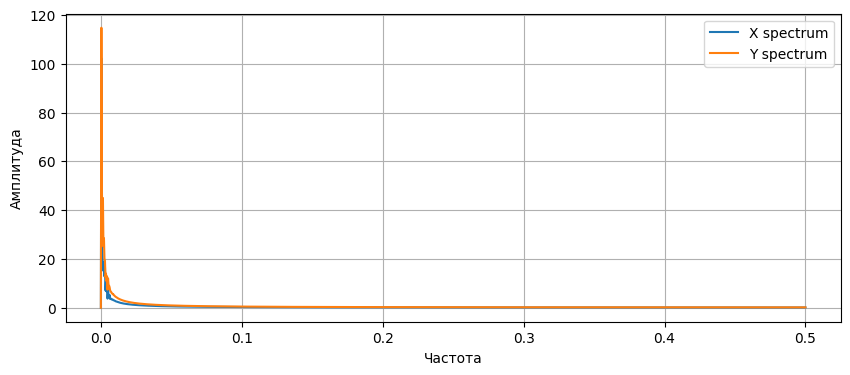

In [331]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(rfftfreq(len(smooth_x), dt), np.abs(rfft(smooth_x - np.mean(smooth_x))), label='X spectrum')
plt.plot(rfftfreq(len(smooth_y), dt), np.abs(rfft(smooth_y - np.mean(smooth_y))), label='Y spectrum')
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid()
plt.show()


In [ ]:

import pickle
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.ndimage import gaussian_filter1d

FILE_PATH = 'data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle'
CUT_NUMBER = 2750
SIGMA = 50
TARGET_ID = 78
NUM_CLOSEST = 2

# === 1. Загрузка данных ===
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)

processor = DataProcessor(data)
coord_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()

# === 5. Определение ближайших роботов ===
target_start = normalized_coord_data[TARGET_ID][0]
distances = {
    rid: np.linalg.norm(np.array(coords[0]) - target_start)
    for rid, coords in normalized_coord_data.items() if rid != TARGET_ID
}
closest_ids = sorted(distances, key=distances.get)[:NUM_CLOSEST]
print(f"Ближайшие к роботу {TARGET_ID}: {closest_ids}")

# === 6. Построение траекторий ===
fig = go.Figure()
colors = ['DarkOrange', 'DarkBlue', 'DarkRed', 'YellowGreen', 'Plum']

selected_ids = [TARGET_ID] + closest_ids
for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # Линия траектории
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', line=dict(color=color, width=1),
                             name=f'Trajectory {rid}'))

    # Начальная точка
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers',
                             marker=dict(color=color, symbol='circle', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'Start {rid}'))

    # Конечная точка
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers',
                             marker=dict(color=color, symbol='x', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'End {rid}'))

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.8,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)

fig.update_xaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
)
fig.update_yaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)

fig.update_xaxes(title_text="X Coordinate")
fig.update_yaxes(title_text="Y Coordinate")
fig.show()
fig.write_html("Trajectories.html")

# === 7. Дополнительно: координаты X(t), Y(t) с сглаживанием ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)

for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    t = np.arange(len(coords))
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # X(t)
    fig.add_trace(go.Scatter(x=t, y=x, mode='lines', line=dict(color=color, width=1),
                             name=f'X, robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             name=f'Smooth X, robot {rid}'), row=1, col=1)

    # Y(t)
    fig.add_trace(go.Scatter(x=t, y=y, mode='lines', line=dict(color=color, width=1),
                             showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             showlegend=False), row=2, col=1)

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.85,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)
fig.update_xaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey', dtick=250)
fig.update_yaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey')
fig.update_xaxes(title_text="Time", row=2, col=1)
fig.update_yaxes(title_text="X Coordinate",dtick=200, row=1, col=1)
fig.update_yaxes(title_text="Y Coordinate", dtick=200, row=2, col=1)
fig.show()
fig.write_html("XY_vs_time.html")
